In [1]:
from collections import deque
import random
import time

import gymnasium as gym
import imageio
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

from deepthink.optimizers import Adam
from deepthink.layers import Dense
from deepthink.model import Model
from deepthink.activations import ReLU
from deepthink.loss import MeanSquaredError

## Solving Cartpole with Deep Q-Networks (DQN)

In this notebook we'll train a Deep Q-Network (DQN) to play the Cartpole game from OpenAI Gym. The Cartpole environment is a simple game in which a pole is attached to a cart. The goal is to move the cart left or right to keep the pole balanced. The game is over if the pole falls past a certain angle from vertical or if the cart moves too far from the center. In reinforcement learning this is known as a "classical control" problem, these ideas are used in many real-world applications such as robotics, autonomous driving, control systems, and more.

Reinforcement learning (RL) is a general framework where agents learn to make decisions by taking actions in an environment to maximize some notion of cumulative reward. The two main components are the **environment**, which represents the problem to be solved, and the **agent**, which represents the learning algorithm. At each time step, the agent takes an action on the environment based on its **policy** (the strategy that the agent uses to determine the next action based on the current state) and the environment returns the **reward** and the next state. The goal is to learn a policy that maximizes the expected cumulative reward.

Because RL works slightly differently from the other examples in this library we use a slightly different approach. We are unable to use the `model.train` method as we need to interact with the environment at each step. Instead, we create a custom environment and agent class that will interact with each other. The agent will use the model to predict the next action and the environment will return the reward and next state. The agent will then learn from this experience.

#### Deep Q-Networks (DQN)

The DQN algorithm was introduced by DeepMind in 2013 in [this paper](https://arxiv.org/pdf/1312.5602). It was able to learn to play many different games on the Atari console, often outperforming humans. The key idea is to use a deep neural network to approximate the Q-function. The Q-function represents the expected cumulative reward of taking an action in a state and following the optimal policy thereafter. The optimal policy is to take the action that maximizes the Q-function.

#### Q-Learning and DQN

The basic idea of Q-learning is that we have a Q-function which provides the optimal action for any given state. In traditional Q-learning, we use a table to represent the Q-function. However, this is not feasible for environments with large state spaces. Instead, we can use a neural network to approximate the Q-function. This is the key idea behind DQN which was introduced by DeepMind in 2013.

#### The Bellman Equation

The Bellman equation is a fundamental recursive formula used to calculate the expected discounted reward of an agent's actions in a given state. It helps in determining the optimal policy by breaking down the value of a decision into immediate rewards and the value of subsequent decisions.

Mathematically, the Bellman equation for the Q-function is given by:

$$
Q(s, a) = r + \gamma \max_{a'} Q(s', a')
$$

where:
- $(Q(s, a))$ is the Q-function, representing the expected cumulative reward of taking action $(a)$ in state $(s)$ and following the optimal policy thereafter.
- $(s)$ is the current state.
- $(a)$ is the action taken.
- $(r)$ is the reward received.
- $(s')$ is the next state.
- $(\gamma)$ is the discount factor, representing the present value of future rewards. 

In essence, the Bellman equation calculates the expected discounted reward by considering both the immediate reward and the best possible future rewards. For more detailed information, you can refer to the [Wikipedia page](https://en.wikipedia.org/wiki/Bellman_equation) on the Bellman equation.

#### Experience Replay

One issue with Q-learning is that the samples are highly correlated, which can lead to inefficient learning. To address this, we can store the agent's experiences (state, action, reward, next state) in a replay buffer and sample mini-batches from it to train the model. This technique is called experience replay. Removing the correlation between samples helps to stabilize and improve the model training.

#### Cartpole Environment

The Cartpole environment is a simple game in which a pole is attached to a cart and the goal is to keep the pole balanced by moving the cart left or right. The state space is 4-dimensional and consists of the cart's position, velocity, pole angle, and pole angular velocity. The agent can take 2 actions: push the cart left or push the cart right. The reward is 1 for each time step the pole remains upright. The episode ends when the pole falls past a certain angle from vertical or the cart moves too far from the center. The maximum episode length is 500, we consider the environment solved if the agent can achieve an average reward of at least 475 over 10 consecutive episodes.

The two examples below show the Cartpole environment before and after training the DQN model. On the left, the agent is taking random actions and the pole falls quickly. On the right, the agent has been trained and is able to balance the pole for the entire episode.

<img src="assets/cartpole_before_training.gif" width="400" align="center">
<img src="assets/cartpole_after_training.gif" width="400" align="center">

In [2]:
# Define the hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 0.001
N_NEURONS = 64
GAMMA = 0.95
MIN_EXP_RATE = 0.1
EXP_DECAY = 0.999

# Set default pyplot parameters (figsize, style, etc.)
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.style.use('dark_background')

In [3]:
def create_gif(env, agent, filename, max_steps=500):
    """
    Create a gif of the agent playing the game

    Parameters
    ----------
    env : gym.Env
        The environment the agent is playing in. Must have the
        render_mode set to 'rgb_array'
    agent : Agent
        The agent playing the game
    filename : str
        The name of the gif file to save
    max_steps : int,default=200
        The maximum number of steps to play the game
    """
    frames = []
    state = env.reset()[0]
    # Reshape the state to be 2D for the model
    state = np.reshape(state, [1, 4])
    done = False
    steps = 0
    while not done and len(frames) < max_steps:
        action = agent.get_best_action(state)
        next_state, reward, done, _, _ = env.step(action)
        next_state = np.reshape(next_state, [1, 4])
        frames.append(env.render())
        state = next_state
        steps += 1

    env.close()
    imageio.mimsave(filename, frames, duration=1/30, loop=0)

In [4]:
class Agent():
    """
    The Agent class is a simple Q-learning agent that uses a 
    neural network to approximate the Q-values for a given state.
    The agent uses an epsilon-greedy policy to explore the
    environment and learn the optimal policy.

    Parameters
    ----------
    state_size : int
        The number of features in the state space (4 for CartPole)
    action_size : int
        The number of actions in the action space (2 for CartPole)

    """
    def __init__(self, state_size: int, action_size: int):
        self.state_size = state_size
        self.action_size = action_size
        
        # Create a replay memory
        self.memory = deque(maxlen=2000)
        # Initialize the hyperparameters and the model
        self.learning_rate = LEARNING_RATE
        self.gamma = GAMMA
        self.exploration_rate = 1.0
        self.exploration_min = MIN_EXP_RATE
        self.exploration_decay = EXP_DECAY
        self.batch_size = BATCH_SIZE
        self.n_neurons = N_NEURONS
        self.loss = MeanSquaredError()
        self.model = self._build_model()

    def _build_model(self) -> Model:
        """
        Build the neural network model for the agent

        The network has 2 hidden layers with ReLU activation
        functions and a final output layer with linear activation.
        """
        self.opt = Adam(learning_rate=self.learning_rate)
        model = Model(self.opt, cost=self.loss, batch_size=self.batch_size)
        model.add_layer(Dense(
            self.n_neurons,
            input_shape=(
                self.batch_size,
                self.state_size)
            ))
        model.add_layer(ReLU())
        model.add_layer(Dense(self.n_neurons))
        model.add_layer(ReLU())
        model.add_layer(Dense(self.action_size))
        # Initialize the model before returning
        model.initialize()

        return model
    
    def get_best_action(self, state: np.ndarray) -> int:
        """
        Get the best action for a given state
        """
        act_values = self.model.get_predictions(state)
        return np.argmax(act_values[0])

    def act(self, state: np.ndarray) -> int:
        """
        Choose an action based on the epsilon-greedy policy
        """
        if np.random.rand() <= self.exploration_rate:
            # Explore: choose a random action
            return random.randrange(self.action_size)
        else:
            # Exploit: choose the best action
            return self.get_best_action(state)

    def remember(
        self, 
        state: np.ndarray,
        action: int,
        reward: int, 
        next_state: np.ndarray,
        done: bool,
    ) -> None:
        """
        Store the state, action, reward, next state, and done flag
        in the replay memory
        """
        self.memory.append((state, action, reward, next_state, done))

    def replay(self) -> None:
        """
        Train the model using the replay memory

        The model is trained using a batch of samples from the
        replay memory. The target Q-values are calculated using
        the Bellman equation. The model is trained using the
        Mean Squared Error loss function and the Adam optimizer.
        After training, the exploration rate is decayed.
        """
        if len(self.memory) < self.batch_size:
            return
        
        # Sample a batch of experiences from the replay memory
        sample_batch = random.sample(self.memory, self.batch_size)
        targets_list = []
        states_list = []
        for state, action, reward, next_state, done in sample_batch:
            target = reward
            if not done:
                # Calculate the target Q-value using the Bellman equation
                next_preds = self.model.forward(next_state)
                target = reward + self.gamma * np.amax(next_preds[0])
            
            # Update the target Q-value for the chosen action
            q_targets = self.model.forward(state)
            q_targets[0][action] = target
            
            targets_list.append(q_targets)
            states_list.append(state)
        
        # Convert the lists to arrays and squeeze the channel dimension
        targets_array = np.squeeze(np.array(targets_list), axis=1)
        states_array = np.squeeze(np.array(states_list), axis=1)
        
        # Train the model using the batch of states and target Q-values
        batch_preds = self.model.forward(states_array)
        loss = self.loss(targets_array, batch_preds)
        grads = self.loss.grads()
        self.model.backward(grads)
        self.opt.update()
        
        # Decay the exploration rate for epsilon-greedy policy
        if self.exploration_rate > self.exploration_min:
            self.exploration_rate *= self.exploration_decay

In [5]:
class CartPole:
    """
    The CartPole class is a simple wrapper around the CartPole
    environment in OpenAI Gym. The class contains a training loop
    that uses a Q-learning agent to learn the optimal policy for
    the CartPole environment.
    """
    def __init__(self):
        # Set the maximum number of episodes
        self.episodes = 500
        self.env = gym.make('CartPole-v1')

        self.state_size = self.env.observation_space.shape[0]
        self.action_size = self.env.action_space.n
        self.agent = Agent(self.state_size, self.action_size)

    def run(self, verbose: bool = True) -> list:
        """
        Run the training loop for the agent

        The agent plays the game for a fixed number of episodes
        and learns the optimal policy using Q-learning. The agent
        uses an epsilon-greedy policy to explore the environment
        and learn the optimal policy.

        The environment is considered solved if the agent scores
        an average of 475 points over the last 10 episodes.

        Parameters
        ----------
        verbose : bool, default=True
            Print the episode number, score, and epsilon value.
    
        Returns
        -------
        scores : list
            A list of scores (as integers) for each episode
        """
        scores = []
        start = time.time()
        for episode in range(self.episodes):
            state = self.env.reset()[0]
            # Reshape to 2D array
            state = np.reshape(state, [1, self.state_size])
            done = False
            index = 0  # Number of steps in the episode
            while not done:
                # Choose an action using the epsilon-greedy policy
                action = self.agent.act(state)

                # Take the action and observe the next state,
                # reward, and done flag
                next_state, reward, done, _, _ = self.env.step(action)
                next_state = np.reshape(next_state, [1, self.state_size])
                # Store the experience in the replay memory
                self.agent.remember(state, action, reward, next_state, done)
                state = next_state
                
                # Train the model using the replay memory
                self.agent.replay()

                index += 1
                if index == 500:  # Maximum number of steps
                    break
                
            scores.append(index + 1)

            # Use mean of last 10 scores to determine if the
            # environment is solved
            if len(scores) > 10 and np.mean(scores[-10:]) > 475:
                if verbose:
                    print(f"Solved after {episode} episodes")
                return scores
            
            if verbose and episode % 10 == 0:
                elapsed_seconds = time.time() - start
                mins, secs = map(int, divmod(elapsed_seconds, 60))
                print(
                    f"Episode {episode} Score: {index + 1}#",
                    f"Epsilon: {self.agent.exploration_rate:.3f}", 
                    f"Time elapsed: {mins}:{secs:02}"
                )

        return scores

In [6]:
# Create an instance of the CartPole class and show the model summary
cartpole = CartPole()
cartpole.agent.model.summary()

Model summary:
_________________________________________________________________
Layer Type                 Output Shape                   Param #
Dense(64)                 (None, 64)                          320
ReLU                      (None, 64)                            0
Dense(64)                 (None, 64)                         4160
ReLU                      (None, 64)                            0
Dense(2)                  (None, 2)                           130
Total params: 4610


In [7]:
# Create a gif to show the agent playing the game before training
render_env = gym.make('CartPole-v1', render_mode='rgb_array')
fpath = 'assets/cartpole_before_training.gif'
create_gif(render_env, cartpole.agent, fpath)

In [8]:
# Train the agent and get the scores for each episode
scores = cartpole.run()

Episode 0 Score: 13# Epsilon: 1.000 Time elapsed: 0:00
Episode 10 Score: 12# Epsilon: 0.865 Time elapsed: 0:00
Episode 20 Score: 10# Epsilon: 0.710 Time elapsed: 0:00
Episode 30 Score: 17# Epsilon: 0.607 Time elapsed: 0:00
Episode 40 Score: 16# Epsilon: 0.519 Time elapsed: 0:00
Episode 50 Score: 79# Epsilon: 0.369 Time elapsed: 0:01
Episode 60 Score: 213# Epsilon: 0.117 Time elapsed: 0:03
Episode 70 Score: 159# Epsilon: 0.100 Time elapsed: 0:06
Episode 80 Score: 280# Epsilon: 0.100 Time elapsed: 0:09
Episode 90 Score: 227# Epsilon: 0.100 Time elapsed: 0:11
Episode 100 Score: 245# Epsilon: 0.100 Time elapsed: 0:12
Episode 110 Score: 10# Epsilon: 0.100 Time elapsed: 0:13
Episode 120 Score: 226# Epsilon: 0.100 Time elapsed: 0:17
Episode 130 Score: 152# Epsilon: 0.100 Time elapsed: 0:23
Episode 140 Score: 150# Epsilon: 0.100 Time elapsed: 0:25
Episode 150 Score: 313# Epsilon: 0.100 Time elapsed: 0:28
Episode 160 Score: 501# Epsilon: 0.100 Time elapsed: 0:33
Solved after 166 episodes


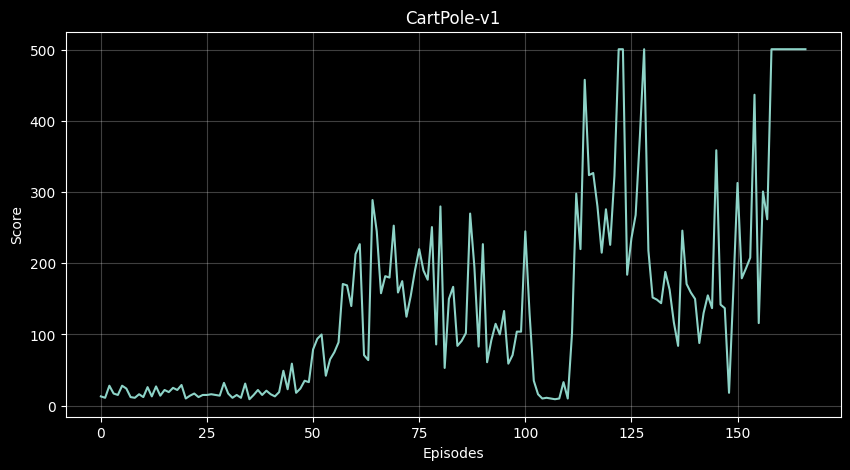

In [9]:
# Show the training scores over time
plt.plot(scores)
plt.xlabel('Episodes')
plt.ylabel('Score')
plt.title('CartPole-v1')
plt.show()

In [10]:
# Create a gif to show the agent playing the game after training
filepath = "assets/cartpole_after_training.gif"
create_gif(render_env, cartpole.agent, filepath)